# Agent1 Sentiment Long-only Backtest

这个 notebook 直接读取现有 backtest CSV 里的 Agent 1 输出，不使用 Agent 2，测试两条基于 sentiment 的 long-only 规则：

1. `POSITIVE -> BUY`, 其他全部 `HOLD`
2. `POSITIVE and confidence >= 0.6 -> BUY`, 其他全部 `HOLD`

它适合用来快速验证：如果只用 Agent 1 sentiment，回测表现会不会比 Agent 2 更干净。

In [15]:
from pathlib import Path
import json
import os
import sys

cwd = Path.cwd()
if (cwd / 'backtest').exists():
    REPO_DIR = cwd
elif (cwd.parent / 'backtest').exists():
    REPO_DIR = cwd.parent
else:
    raise RuntimeError(f'Could not locate repo root from cwd={cwd}')

if str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))

OUTPUT_DIR = REPO_DIR / 'output'
RESULTS_CSV = OUTPUT_DIR / 'alpaca_news_backtest_results.csv'
SENTIMENT_OUT_DIR = OUTPUT_DIR / 'agent1_sentiment_backtests'
SENTIMENT_OUT_DIR.mkdir(parents=True, exist_ok=True)

print('Repo dir      :', REPO_DIR)
print('Results CSV   :', RESULTS_CSV)
print('Output dir    :', SENTIMENT_OUT_DIR)


Repo dir      : c:\Project\FinGPT\FinGPT_Part2
Results CSV   : c:\Project\FinGPT\FinGPT_Part2\output\alpaca_news_backtest_results.csv
Output dir    : c:\Project\FinGPT\FinGPT_Part2\output\agent1_sentiment_backtests


In [16]:
import pandas as pd

from backtest.backtester import augment_metrics_with_demo_fields, compute_metrics

results_df = pd.read_csv(RESULTS_CSV)
print('Rows loaded:', len(results_df))
print('Columns:', list(results_df.columns))

required = ['ticker', 'sentiment_label', 'sentiment_confidence', 'realized_return']
missing = [c for c in required if c not in results_df.columns]
if missing:
    raise ValueError(f'Missing required columns for sentiment backtest: {missing}')

display(results_df.head(5))


Rows loaded: 126
Columns: ['ticker', 'headline', 'fingerprint_ticker', 'signal_ticker', 'start_date', 'end_date', 'article_text', 'fingpt_label', 'sentiment_label', 'sentiment_score', 'sentiment_confidence', 'sentiment_logprob_POSITIVE', 'sentiment_logprob_NEGATIVE', 'sentiment_logprob_NEUTRAL', 'sentiment_prob_POSITIVE', 'sentiment_prob_NEGATIVE', 'sentiment_prob_NEUTRAL', 'event_type', 'event_type_confidence', 'event_type_margin', 'event_type_method', 'event_logprob_A', 'event_logprob_B', 'event_logprob_C', 'event_logprob_D', 'event_logprob_E', 'event_logprob_F', 'event_logprob_G', 'event_prob_A', 'event_prob_B', 'event_prob_C', 'event_prob_D', 'event_prob_E', 'event_prob_F', 'event_prob_G', 'direction', 'confidence', 'raw_signal_logprob_A', 'raw_signal_logprob_B', 'raw_signal_logprob_C', 'pmi_null_logprob_A', 'pmi_null_logprob_B', 'pmi_null_logprob_C', 'pmi_adjusted_logit_A', 'pmi_adjusted_logit_B', 'pmi_adjusted_logit_C', 'signal_prob_A', 'signal_prob_B', 'signal_prob_C', 'pmi_alph

,ticker,headline,fingerprint_ticker,signal_ticker,start_date,end_date,article_text,fingpt_label,sentiment_label,sentiment_score,...,signal_filter_reason,signal_direction,signal_confidence,strategy_tag,realized_return,position,strategy_return,pass_reason,skipped_reason,price_fetch_error_reason
0,GLD,Venezuela Accuses US Of 'Greatest Extortion' I...,GLD,GLD,2025-12-29,2026-01-05,Ticker: GLD\n\nNews 1\nHeadline: Venezuela Acc...,no_label_provided,NEGATIVE,-1.0,...,NaN,neutral,0.369843,event_driven,-0.000803,0.0,-0.000000,NaN,NaN,NaN
1,GLD,"Investment Trends For 2026: What's In, What's Out",GLD,GLD,2026-01-05,2026-01-12,Ticker: GLD\n\nNews 1\nHeadline: Investment Tr...,no_label_provided,NEUTRAL,0.0,...,NaN,long,0.414606,event_driven,0.013969,1.0,0.013969,NaN,NaN,NaN
2,GLD,"Gold's 2025 Performance Shifts Ground In ETFs,...",GLD,GLD,2026-01-12,2026-01-20,Ticker: GLD\n\nNews 1\nHeadline: Gold's 2025 P...,no_label_provided,POSITIVE,1.0,...,NaN,long,0.417848,event_driven,-0.002226,1.0,-0.002226,NaN,NaN,NaN
3,GLD,Benzinga Market Summary: Gold And Silver Close...,GLD,GLD,2026-01-20,2026-01-26,Ticker: GLD\n\nNews 1\nHeadline: Benzinga Mark...,no_label_provided,NEUTRAL,0.0,...,NaN,neutral,0.515605,event_driven,0.047504,0.0,0.000000,NaN,NaN,NaN
4,GLD,Ron DeSantis Blames Dollar Instability As Silv...,GLD,GLD,2026-01-26,2026-02-02,Ticker: GLD\n\nNews 1\nHeadline: Ron DeSantis ...,no_label_provided,POSITIVE,1.0,...,NaN,long,0.438784,event_driven,-0.042501,1.0,-0.042501,NaN,NaN,NaN


In [17]:
import numpy as np
import matplotlib.pyplot as plt

def _normalize_skip_reason(value):
    if pd.isna(value):
        return ''
    return str(value).strip()

def build_agent1_sentiment_strategy(source_df: pd.DataFrame, *, confidence_threshold=None, strategy_name='sentiment_long_only') -> pd.DataFrame:
    df = source_df.copy()

    if 'signal_direction' not in df.columns:
        df['signal_direction'] = ''
    if 'direction' not in df.columns:
        df['direction'] = ''
    if 'signal_confidence' not in df.columns:
        df['signal_confidence'] = np.nan
    if 'confidence' not in df.columns:
        df['confidence'] = np.nan
    if 'position' not in df.columns:
        df['position'] = np.nan
    if 'strategy_return' not in df.columns:
        df['strategy_return'] = np.nan
    if 'strategy_tag' not in df.columns:
        df['strategy_tag'] = ''
    if 'signal_filter_reason' not in df.columns:
        df['signal_filter_reason'] = ''
    if 'signal_filter_forced_hold' not in df.columns:
        df['signal_filter_forced_hold'] = False
    if 'skipped_reason' not in df.columns:
        df['skipped_reason'] = ''
    if 'pass_reason' not in df.columns:
        df['pass_reason'] = ''

    text_columns = ['signal_direction', 'direction', 'strategy_tag', 'signal_filter_reason', 'skipped_reason', 'pass_reason']
    for col in text_columns:
        df[col] = df[col].astype(object)

    for idx in df.index:
        row = df.loc[idx]
        sentiment = '' if pd.isna(row.get('sentiment_label')) else str(row.get('sentiment_label')).strip().upper()
        skip_reason = _normalize_skip_reason(row.get('skipped_reason', ''))
        realized = row.get('realized_return')
        realized_is_valid = pd.notna(realized)

        raw_conf = row.get('sentiment_confidence')
        sentiment_conf = float(raw_conf) if pd.notna(raw_conf) else np.nan

        has_positive = sentiment == 'POSITIVE'
        passes_threshold = True if confidence_threshold is None else (pd.notna(sentiment_conf) and sentiment_conf >= confidence_threshold)
        take_long = has_positive and passes_threshold

        df.at[idx, 'signal_direction'] = 'long' if take_long else 'neutral'
        df.at[idx, 'direction'] = 'long' if take_long else 'neutral'
        df.at[idx, 'signal_confidence'] = sentiment_conf
        df.at[idx, 'confidence'] = sentiment_conf
        df.at[idx, 'position'] = 1 if take_long else 0
        df.at[idx, 'strategy_tag'] = strategy_name
        df.at[idx, 'signal_filter_forced_hold'] = bool(not take_long)

        if take_long:
            df.at[idx, 'signal_filter_reason'] = ''
        elif sentiment != 'POSITIVE':
            df.at[idx, 'signal_filter_reason'] = 'sentiment_not_positive'
        else:
            df.at[idx, 'signal_filter_reason'] = 'sentiment_confidence_below_threshold'

        if realized_is_valid:
            df.at[idx, 'strategy_return'] = (1 if take_long else 0) * float(realized)
            if sentiment:
                df.at[idx, 'skipped_reason'] = ''
            elif skip_reason:
                df.at[idx, 'skipped_reason'] = skip_reason
            else:
                df.at[idx, 'skipped_reason'] = 'sentiment_missing'
        else:
            df.at[idx, 'strategy_return'] = np.nan
            if skip_reason:
                df.at[idx, 'skipped_reason'] = skip_reason
            else:
                df.at[idx, 'skipped_reason'] = 'price_fetch_failed'

    return df

def summarize_strategy(df: pd.DataFrame) -> dict:
    metrics = compute_metrics(df)
    return augment_metrics_with_demo_fields(df, metrics)

def plot_strategy_dashboard(df: pd.DataFrame, title: str):
    ok = df[df['skipped_reason'].fillna('') == ''].copy()
    if 'end_date' in ok.columns:
        ok['end_date'] = pd.to_datetime(ok['end_date'], errors='coerce')
        ok = ok.sort_values(['end_date', 'ticker'], kind='stable')
    x = ok['end_date'] if 'end_date' in ok.columns else ok.index
    sr = ok['strategy_return'].fillna(0.0).astype(float)
    equity = (1.0 + sr).cumprod()
    drawdown = equity / equity.cummax() - 1.0
    rolling_win = (sr > 0).astype(float).rolling(12, min_periods=1).mean()
    rolling_ret = sr.rolling(12, min_periods=1).mean()

    signal_bucket = ok['signal_direction'].map({'long': 'BUY', 'neutral': 'HOLD', 'short': 'SELL'}).fillna('UNKNOWN')
    avg_returns = ok.assign(signal_bucket=signal_bucket).groupby('signal_bucket')['realized_return'].mean()
    ordered = pd.Series(index=['BUY', 'SELL', 'HOLD'], dtype=float)
    for key in ordered.index:
        ordered.loc[key] = avg_returns.get(key, np.nan)

    fig, axes = plt.subplots(3, 2, figsize=(16, 16))
    axes = axes.ravel()
    axes[0].plot(x, equity, color='navy', linewidth=2)
    axes[0].set_title(f'{title} - Cumulative Return / Equity Curve')
    axes[1].fill_between(x, drawdown, 0, color='firebrick', alpha=0.35)
    axes[1].set_title(f'{title} - Drawdown Curve')
    axes[2].hist(sr.dropna(), bins=30, color='darkslateblue', alpha=0.8)
    axes[2].set_title(f'{title} - Histogram of Trade/Period Returns')
    axes[3].plot(x, rolling_win, color='darkgreen', linewidth=2)
    axes[3].set_ylim(0, 1)
    axes[3].set_title(f'{title} - Rolling Win Rate (12)')
    axes[4].plot(x, rolling_ret, color='darkorange', linewidth=2)
    axes[4].axhline(0, color='black', linewidth=1, alpha=0.5)
    axes[4].set_title(f'{title} - Rolling Return (12)')
    axes[5].bar(ordered.index, ordered.values, color=['seagreen', 'indianred', 'gray'])
    axes[5].axhline(0, color='black', linewidth=1, alpha=0.5)
    axes[5].set_title(f'{title} - Average Return By Signal')
    for ax in axes[:5]:
        ax.grid(alpha=0.2)
    plt.tight_layout()
    return ok, fig


In [18]:
sentiment_only_df = build_agent1_sentiment_strategy(
    results_df,
    confidence_threshold=None,
    strategy_name='agent1_sentiment_only_long',
)
confidence_filtered_df = build_agent1_sentiment_strategy(
    results_df,
    confidence_threshold=0.6,
    strategy_name='agent1_confidence_filtered_long',
)

sentiment_only_metrics = summarize_strategy(sentiment_only_df)
confidence_filtered_metrics = summarize_strategy(confidence_filtered_df)

comparison = pd.DataFrame([
    {'strategy': 'Agent1 sentiment-only long', **sentiment_only_metrics},
    {'strategy': 'Agent1 confidence-filtered long (>= 0.6)', **confidence_filtered_metrics},
])

display(comparison)


,strategy,total_rows,successful_rows,skip_rate,direction_accuracy,long_trade_count,short_trade_count,neutral_count,num_trades,coverage,...,gross_return,annualized_sharpe,max_drawdown,vs_fingpt_accuracy,signal_filter_forced_hold_rate,event_type_breakdown,avg_sentiment_confidence,avg_signal_confidence,avg_pmi_alpha_used,avg_calibration_T
0,Agent1 sentiment-only long,126,124,0.015873,0.161290,37,0,87,37,0.298387,...,0.055767,0.114346,0.252453,no_label_provided,0.701613,"{'EARNINGS': {'mean_return': 0.005663, 'n_rows...",0.551413,0.551413,0.0,1.2
1,Agent1 confidence-filtered long (>= 0.6),126,124,0.015873,0.129032,19,0,105,19,0.153226,...,0.332524,1.285334,0.061317,no_label_provided,0.846774,"{'EARNINGS': {'mean_return': 0.008637, 'n_rows...",0.551413,0.551413,0.0,1.2


In [19]:
sentiment_only_csv = SENTIMENT_OUT_DIR / 'agent1_sentiment_only_long.csv'
confidence_filtered_csv = SENTIMENT_OUT_DIR / 'agent1_confidence_filtered_long.csv'
comparison_json = SENTIMENT_OUT_DIR / 'agent1_sentiment_strategy_comparison.json'

sentiment_only_df.to_csv(sentiment_only_csv, index=False)
confidence_filtered_df.to_csv(confidence_filtered_csv, index=False)
comparison_json.write_text(json.dumps(comparison.to_dict(orient='records'), indent=2, default=str), encoding='utf-8')

print('Saved:', sentiment_only_csv)
print('Saved:', confidence_filtered_csv)
print('Saved:', comparison_json)


Saved: c:\Project\FinGPT\FinGPT_Part2\output\agent1_sentiment_backtests\agent1_sentiment_only_long.csv
Saved: c:\Project\FinGPT\FinGPT_Part2\output\agent1_sentiment_backtests\agent1_confidence_filtered_long.csv
Saved: c:\Project\FinGPT\FinGPT_Part2\output\agent1_sentiment_backtests\agent1_sentiment_strategy_comparison.json


In [20]:
print('Agent1 sentiment-only signal distribution:')
display(sentiment_only_df['signal_direction'].value_counts(dropna=False).to_frame(name='count'))

print('Agent1 confidence-filtered signal distribution:')
display(confidence_filtered_df['signal_direction'].value_counts(dropna=False).to_frame(name='count'))

print('Average realized return by sentiment label in source CSV:')
display(results_df.groupby('sentiment_label', dropna=False)['realized_return'].mean().to_frame(name='avg_realized_return'))


Agent1 sentiment-only signal distribution:


,count
signal_direction,
neutral,89
long,37


Agent1 confidence-filtered signal distribution:


,count
signal_direction,
neutral,107
long,19


Average realized return by sentiment label in source CSV:


,avg_realized_return
sentiment_label,
NEGATIVE,-0.000042
NEUTRAL,0.009924
POSITIVE,0.001507
NaN,NaN


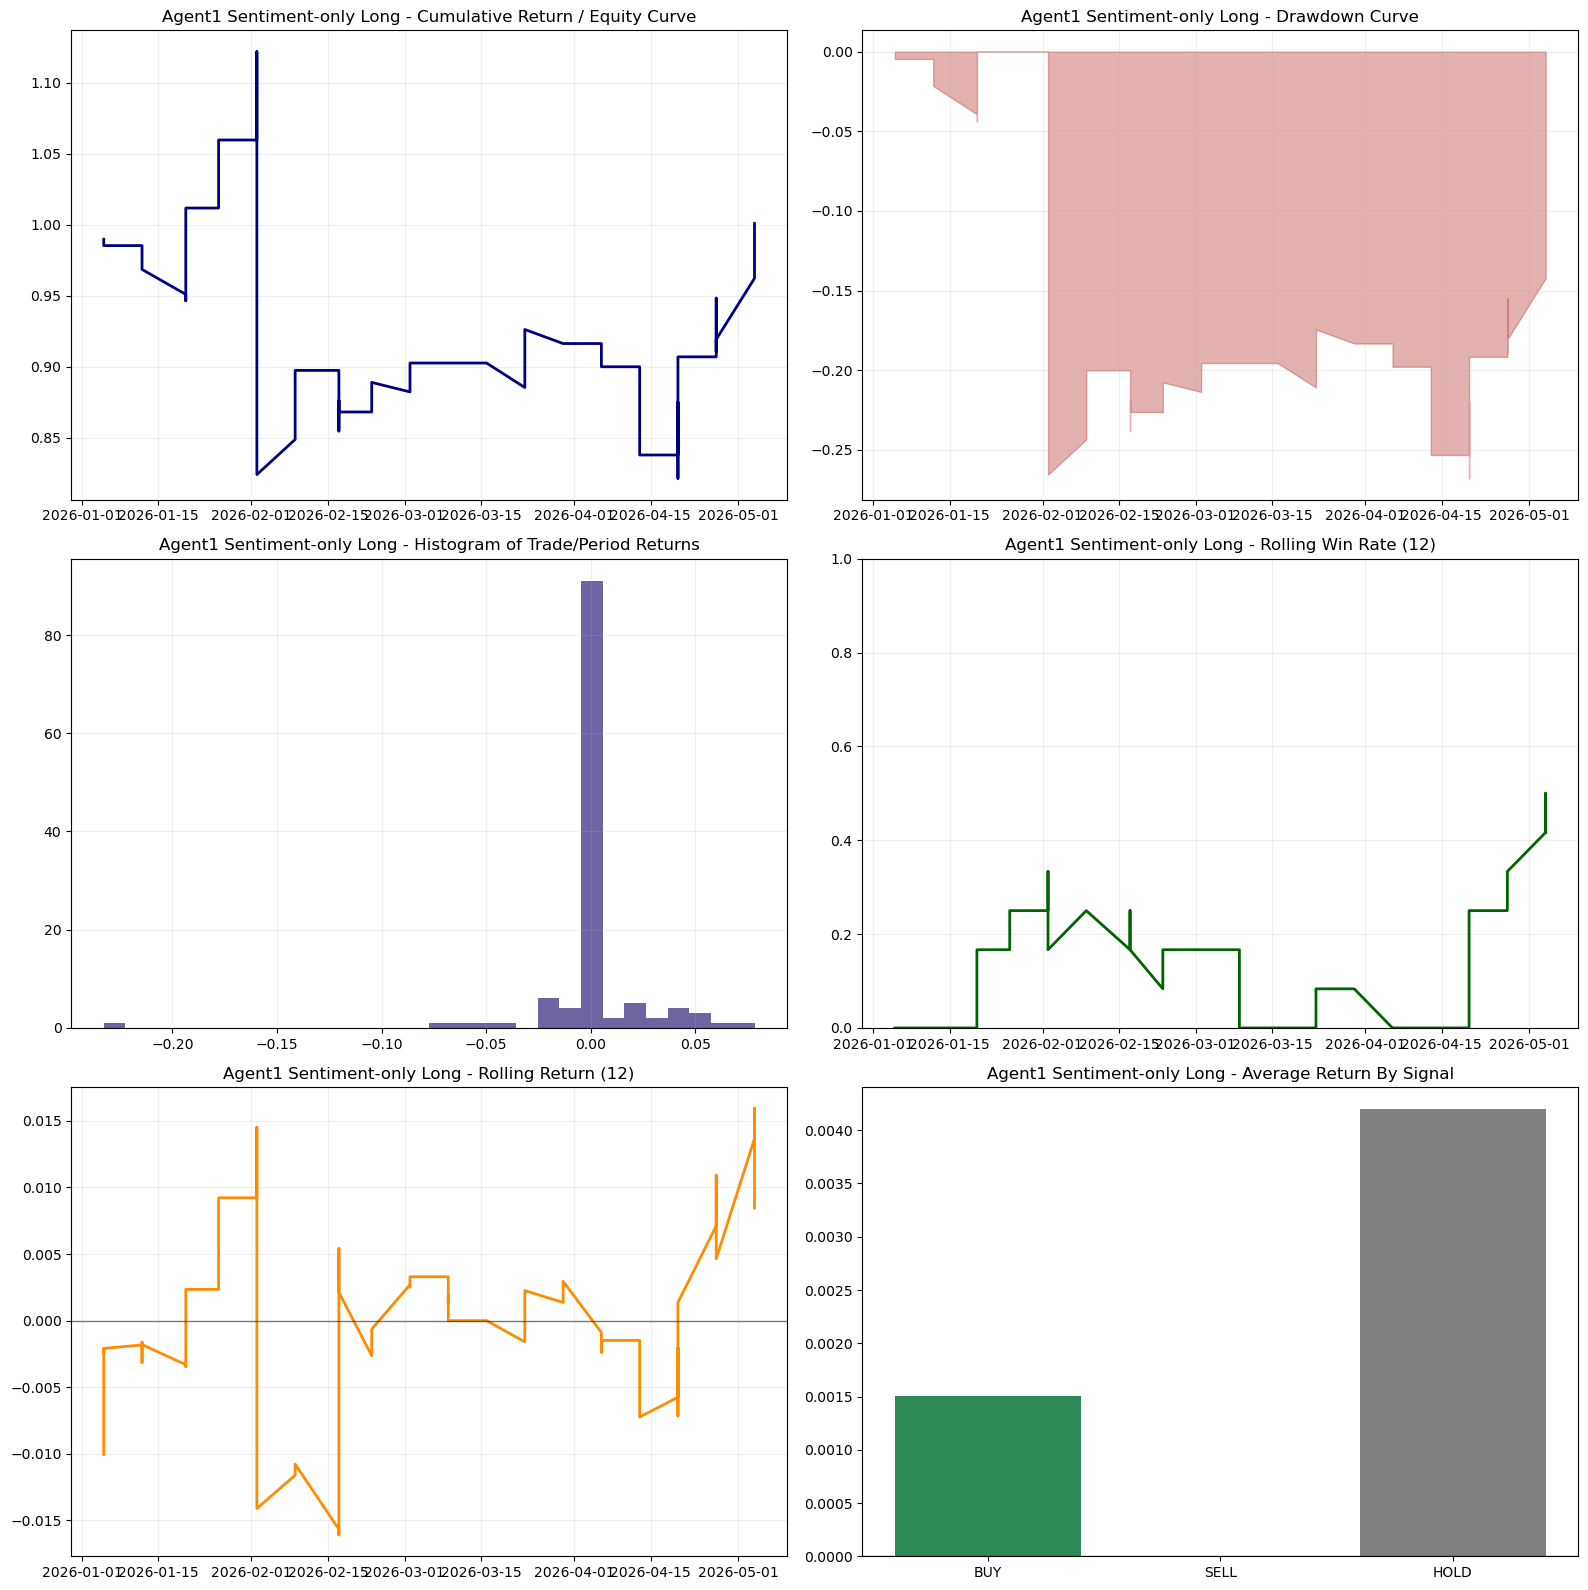

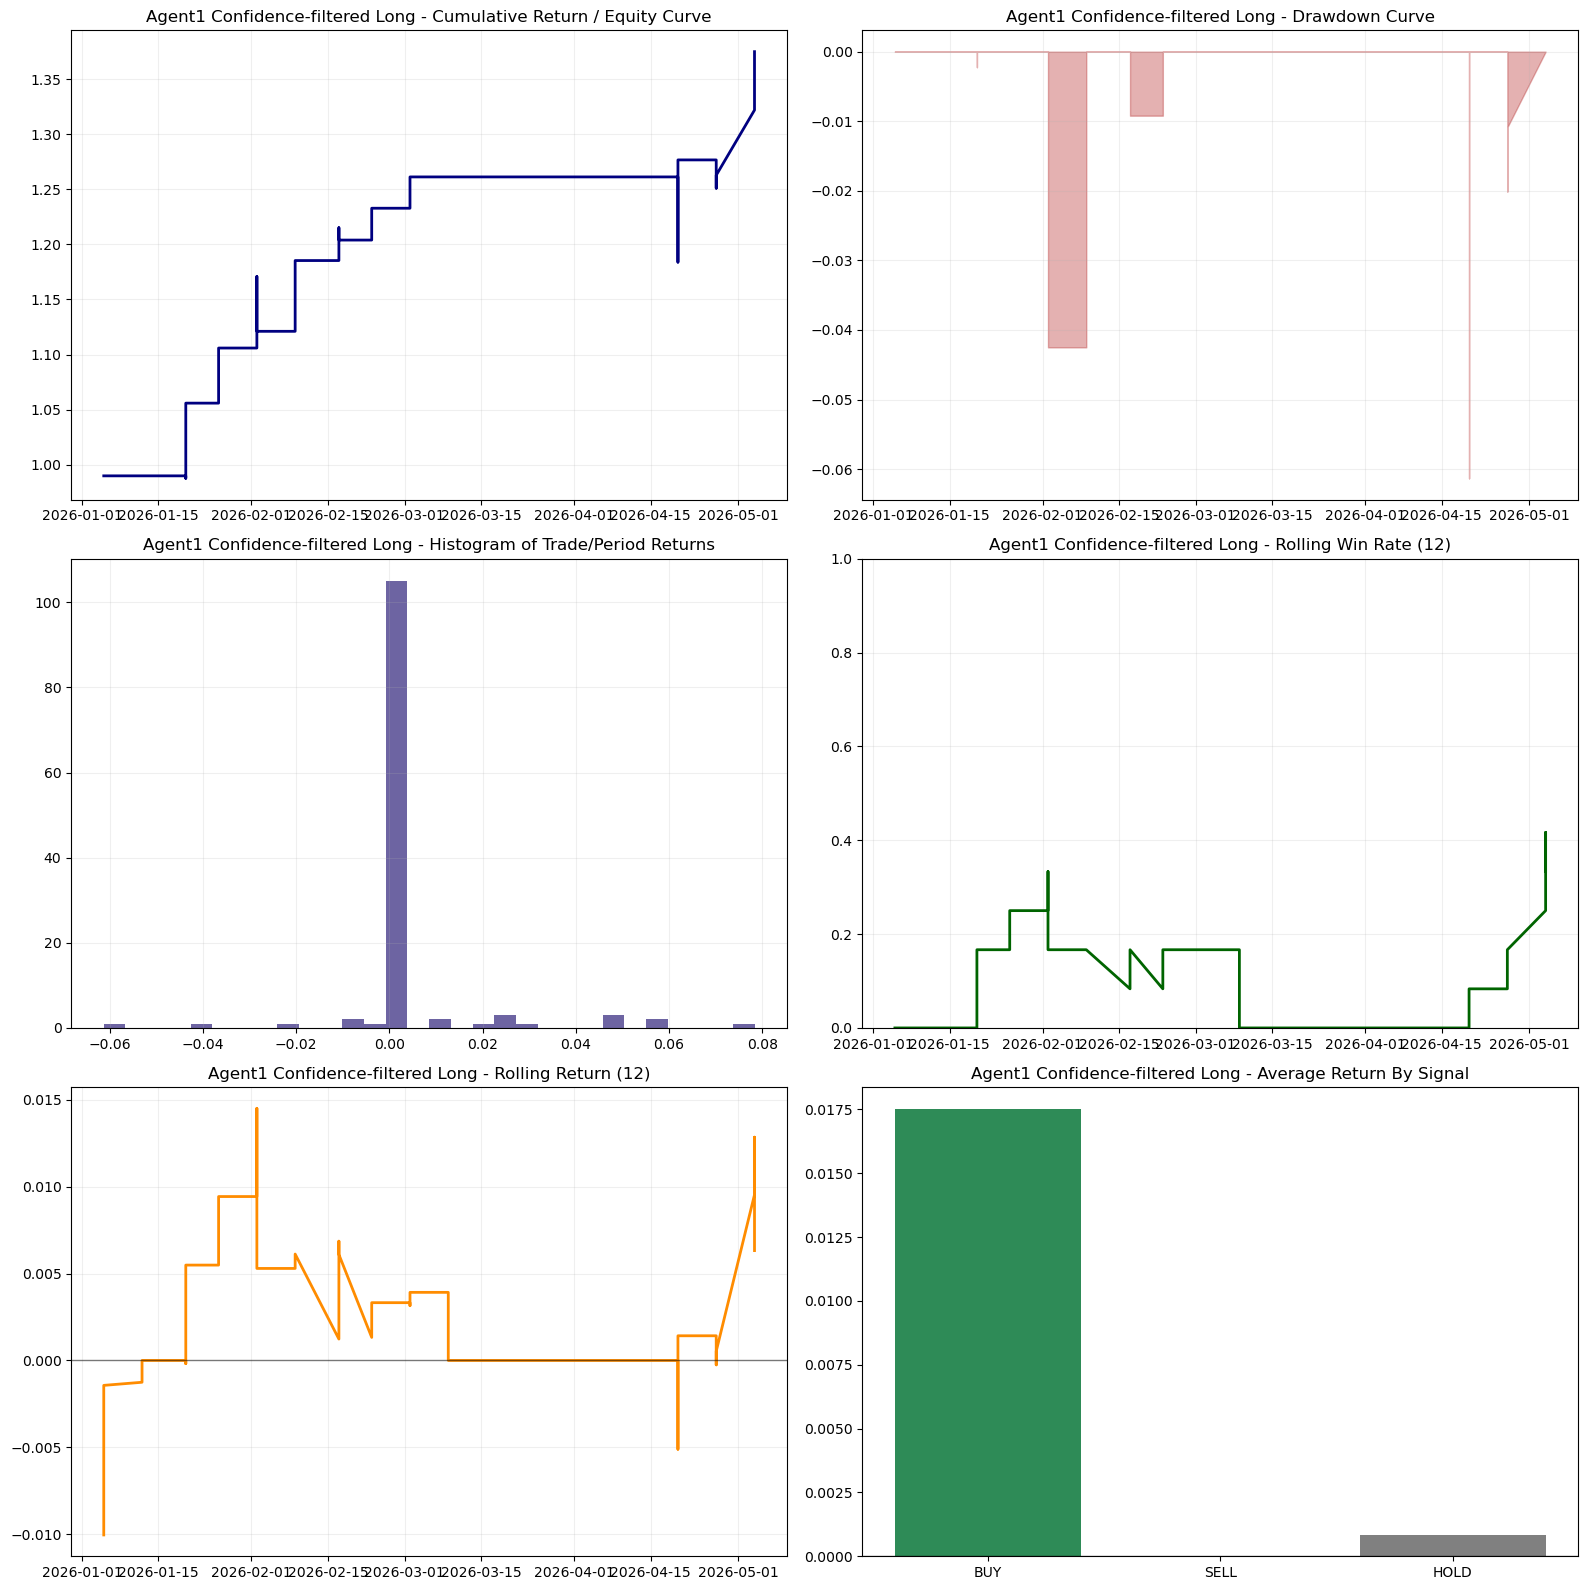

Saved dashboards to c:\Project\FinGPT\FinGPT_Part2\output\agent1_sentiment_backtests


In [21]:
sentiment_ok, fig1 = plot_strategy_dashboard(sentiment_only_df, 'Agent1 Sentiment-only Long')
filtered_ok, fig2 = plot_strategy_dashboard(confidence_filtered_df, 'Agent1 Confidence-filtered Long')
plt.show()

fig1.savefig(SENTIMENT_OUT_DIR / 'agent1_sentiment_only_long_dashboard.png', dpi=160, bbox_inches='tight')
fig2.savefig(SENTIMENT_OUT_DIR / 'agent1_confidence_filtered_long_dashboard.png', dpi=160, bbox_inches='tight')
print('Saved dashboards to', SENTIMENT_OUT_DIR)
